# Final Assignment Book


We were given the dataset which is used in this notebook where I did some visualisation and later built a model to help in creating a business proposal baswhich will be data driven with quentified impact and created an EDA(Exploratory Data Analysis)

## Importing the Libraries


In [65]:
# Importing libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import math
from scipy import stats
from sklearn.preprocessing import LabelEncoder
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix, roc_auc_score, f1_score
import lightgbm as lgb
from lightgbm import LGBMClassifier
from sklearn.model_selection import RandomizedSearchCV
from scipy.stats import randint, uniform


# Set plot style
sns.set(style="whitegrid")

 ## Mounting Google drive


In [3]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [4]:
# Specify the directory where this notebook is located after %cd.
%cd "/content/drive/MyDrive/GCI_Global/Final Assignment"

/content/drive/MyDrive/GCI_Global/Final Assignment


In [5]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


To see if data exist in the path mentioned

In [6]:
import os
from pathlib import Path

# Automatically get the current working directory
current_dir = Path(os.getcwd())

# Define file paths using pathlib
final = current_dir / "dataset" / "data.csv"

# Check if path exists
if final.exists():
    print("All files exist and path is correctly set.")
else:
    print("Some files are missing or path is not correctly set.")

All files exist and path is correctly set.


## Data Analysis

Loading data


In [7]:
final_data = pd.read_csv(final)

Printing the data

In [8]:
# Check train data
print(f"train shape: {final_data.shape}")
final_data.head(5)

train shape: (1470, 44)


,Age,Attrition,BusinessTravel,Department,DistanceFromHome,Education,EducationField,EmployeeCount,EmployeeNumber,EnvironmentSatisfaction,...,RemoteWork,MonthlyIncome,StressRating,WelfareBenefits,InHouseFacility,ExternalFacility,ExtendedLeave,FlexibleWork,StressSelfReported,Year
0,41,Yes,Travel_Rarely,Sales,1,2,Life Sciences,1,1,2,...,1,5224,4,1,0,0,0,0,1,2023
1,49,No,Travel_Frequently,Research & Development,8,1,Life Sciences,1,2,3,...,3,6863,2,4,1,0,0,1,1,2023
2,37,Yes,Travel_Rarely,Research & Development,2,2,Other,1,4,4,...,2,7612,3,2,1,0,0,0,1,2023
3,33,No,Travel_Frequently,Research & Development,3,4,Life Sciences,1,5,4,...,2,11245,1,4,1,1,1,1,1,2023
4,27,No,Travel_Rarely,Research & Development,2,1,Medical,1,7,1,...,2,3029,3,2,0,0,0,0,3,2023


Duplicates in the data


In [9]:
final_data[final_data.duplicated(subset=['EmployeeNumber'], keep=False)]

,Age,Attrition,BusinessTravel,Department,DistanceFromHome,Education,EducationField,EmployeeCount,EmployeeNumber,EnvironmentSatisfaction,...,RemoteWork,MonthlyIncome,StressRating,WelfareBenefits,InHouseFacility,ExternalFacility,ExtendedLeave,FlexibleWork,StressSelfReported,Year
10,35,No,Travel_Rarely,Research & Development,16,3,Medical,1,14,1,...,3,8320,3,2,0,0,0,1,2,2023
60,32,No,Travel_Rarely,Research & Development,1,3,Medical,1,78,1,...,5,5012,3,1,0,0,0,0,1,2023
75,31,No,Travel_Rarely,Research & Development,8,4,Life Sciences,1,98,3,...,5,7715,2,3,1,1,0,1,3,2023
148,36,No,Travel_Rarely,Research & Development,25,4,Medical,1,1014,3,...,3,8856,2,4,1,1,1,1,1,2024
201,49,No,Non-Travel,Research & Development,18,4,Life Sciences,1,275,4,...,5,5619,1,2,1,1,0,1,1,2023
203,36,No,Travel_Rarely,Research & Development,16,3,Medical,1,14,3,...,4,8330,2,4,1,1,1,1,2,2024
228,35,No,Travel_Frequently,Sales,1,3,Marketing,1,314,3,...,3,6157,3,2,0,0,0,0,1,2023
257,40,No,Travel_Rarely,Research & Development,2,2,Medical,1,352,1,...,2,5877,2,1,0,0,0,0,1,2023
304,33,No,Travel_Rarely,Research & Development,1,3,Medical,1,78,3,...,3,5002,3,3,0,0,0,0,3,2024
308,58,No,Non-Travel,Research & Development,1,4,Life Sciences,1,422,4,...,2,7341,3,2,0,0,0,0,3,2023


Total Number of all Dupicates

In [10]:
print("The total number of all duplicates based on the employee number:", final_data.duplicated(subset=['EmployeeNumber']).sum())

The total number of all duplicates based on the employee number: 28


Null values

In [11]:
# Check missing values of train dat
final_data.isnull().sum()

,0
Age,0
Attrition,0
BusinessTravel,0
Department,0
DistanceFromHome,0
Education,0
EducationField,0
EmployeeCount,0
EmployeeNumber,0
EnvironmentSatisfaction,0


In [12]:
final_data.info()
# showing the datatype of each column

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1470 entries, 0 to 1469
Data columns (total 44 columns):
 #   Column                    Non-Null Count  Dtype 
---  ------                    --------------  ----- 
 0   Age                       1470 non-null   int64 
 1   Attrition                 1470 non-null   object
 2   BusinessTravel            1470 non-null   object
 3   Department                1470 non-null   object
 4   DistanceFromHome          1470 non-null   int64 
 5   Education                 1470 non-null   int64 
 6   EducationField            1470 non-null   object
 7   EmployeeCount             1470 non-null   int64 
 8   EmployeeNumber            1470 non-null   int64 
 9   EnvironmentSatisfaction   1470 non-null   int64 
 10  Gender                    1470 non-null   object
 11  PerformanceIndex          1470 non-null   int64 
 12  JobInvolvement            1470 non-null   int64 
 13  JobLevel                  1470 non-null   int64 
 14  JobRole                 

In [13]:
# describe
final_data.describe()

,Age,DistanceFromHome,Education,EmployeeCount,EmployeeNumber,EnvironmentSatisfaction,PerformanceIndex,JobInvolvement,JobLevel,JobSatisfaction,...,RemoteWork,MonthlyIncome,StressRating,WelfareBenefits,InHouseFacility,ExternalFacility,ExtendedLeave,FlexibleWork,StressSelfReported,Year
count,1470.000000,1470.000000,1470.000000,1470.0,1470.000000,1470.000000,1470.000000,1470.000000,1470.000000,1470.000000,...,1470.000000,1470.000000,1470.000000,1470.000000,1470.000000,1470.000000,1470.000000,1470.000000,1470.000000,1470.000000
mean,36.895238,9.236735,2.910204,1.0,1022.185034,2.721769,65.891156,2.729932,2.074830,2.728571,...,2.824490,6922.257143,2.499320,2.500000,0.596599,0.293878,0.252381,0.551020,2.104082,2023.200000
std,9.151321,8.129551,1.025259,0.0,602.769132,1.093082,20.329428,0.711561,1.109943,1.102846,...,1.229521,1977.100821,0.883052,1.131124,0.490747,0.455692,0.434526,0.497559,0.949750,0.400136
min,18.000000,1.000000,1.000000,1.0,1.000000,1.000000,30.000000,1.000000,1.000000,1.000000,...,0.000000,1329.000000,1.000000,1.000000,0.000000,0.000000,0.000000,0.000000,1.000000,2023.000000
25%,30.000000,2.000000,2.000000,1.0,486.250000,2.000000,48.000000,2.000000,1.000000,2.000000,...,2.000000,5542.250000,2.000000,1.000000,0.000000,0.000000,0.000000,0.000000,1.000000,2023.000000
50%,36.000000,7.000000,3.000000,1.0,1018.500000,3.000000,66.000000,3.000000,2.000000,3.000000,...,3.000000,6814.500000,2.000000,2.000000,1.000000,0.000000,0.000000,1.000000,2.000000,2023.000000
75%,43.000000,14.000000,4.000000,1.0,1554.750000,4.000000,83.750000,3.000000,3.000000,4.000000,...,4.000000,8264.750000,3.000000,4.000000,1.000000,1.000000,1.000000,1.000000,3.000000,2023.000000
max,60.000000,29.000000,5.000000,1.0,2068.000000,4.000000,100.000000,4.000000,5.000000,4.000000,...,5.000000,12612.000000,5.000000,4.000000,1.000000,1.000000,1.000000,1.000000,5.000000,2024.000000


## **Data Cleaning**

First want clean the data and clear the issue regarding the EmployeeNumber as there are some duplicates and ,and it would be better if I remove the duplicates to make sure that we dont have duplicates in the dataset as for Null values the dataset contain no null values making data cleaning easier

For here I decided that I will drop the current EmployeeNumber column and then recreate it with an incremental numbering and allocate it to dataset

In [14]:
#  first droping the column EmployeeNumber
dataset = final_data.drop(["EmployeeNumber"], axis=1)

In [15]:
dataset.head()

,Age,Attrition,BusinessTravel,Department,DistanceFromHome,Education,EducationField,EmployeeCount,EnvironmentSatisfaction,Gender,...,RemoteWork,MonthlyIncome,StressRating,WelfareBenefits,InHouseFacility,ExternalFacility,ExtendedLeave,FlexibleWork,StressSelfReported,Year
0,41,Yes,Travel_Rarely,Sales,1,2,Life Sciences,1,2,Female,...,1,5224,4,1,0,0,0,0,1,2023
1,49,No,Travel_Frequently,Research & Development,8,1,Life Sciences,1,3,Male,...,3,6863,2,4,1,0,0,1,1,2023
2,37,Yes,Travel_Rarely,Research & Development,2,2,Other,1,4,Male,...,2,7612,3,2,1,0,0,0,1,2023
3,33,No,Travel_Frequently,Research & Development,3,4,Life Sciences,1,4,Female,...,2,11245,1,4,1,1,1,1,1,2023
4,27,No,Travel_Rarely,Research & Development,2,1,Medical,1,1,Male,...,2,3029,3,2,0,0,0,0,3,2023


In [16]:
# recreating employeenumber with incrementing nummber
dataset['EmployeeNumber'] = range(1, len(dataset) + 1)

# displaying the dataset
dataset.head()

,Age,Attrition,BusinessTravel,Department,DistanceFromHome,Education,EducationField,EmployeeCount,EnvironmentSatisfaction,Gender,...,MonthlyIncome,StressRating,WelfareBenefits,InHouseFacility,ExternalFacility,ExtendedLeave,FlexibleWork,StressSelfReported,Year,EmployeeNumber
0,41,Yes,Travel_Rarely,Sales,1,2,Life Sciences,1,2,Female,...,5224,4,1,0,0,0,0,1,2023,1
1,49,No,Travel_Frequently,Research & Development,8,1,Life Sciences,1,3,Male,...,6863,2,4,1,0,0,1,1,2023,2
2,37,Yes,Travel_Rarely,Research & Development,2,2,Other,1,4,Male,...,7612,3,2,1,0,0,0,1,2023,3
3,33,No,Travel_Frequently,Research & Development,3,4,Life Sciences,1,4,Female,...,11245,1,4,1,1,1,1,1,2023,4
4,27,No,Travel_Rarely,Research & Development,2,1,Medical,1,1,Male,...,3029,3,2,0,0,0,0,3,2023,5


## **Data Visualisation**

This section shows some of graphs of attrition in relation to different factors
1. General Attrition
2. Depending on Age
3. Depending on Gender
4. Depending on Marital Status
5. Depending on Education
6. Depending on Education Field
7. Depending on Overtime
8. Depending On worklife balance
9. Depending on Job Involvement
10. Depending on Job Satification
11. Depending on Monthly Income
12. Depending on Job Role
13. Depending on WelfareBenefits


###  General Attrition

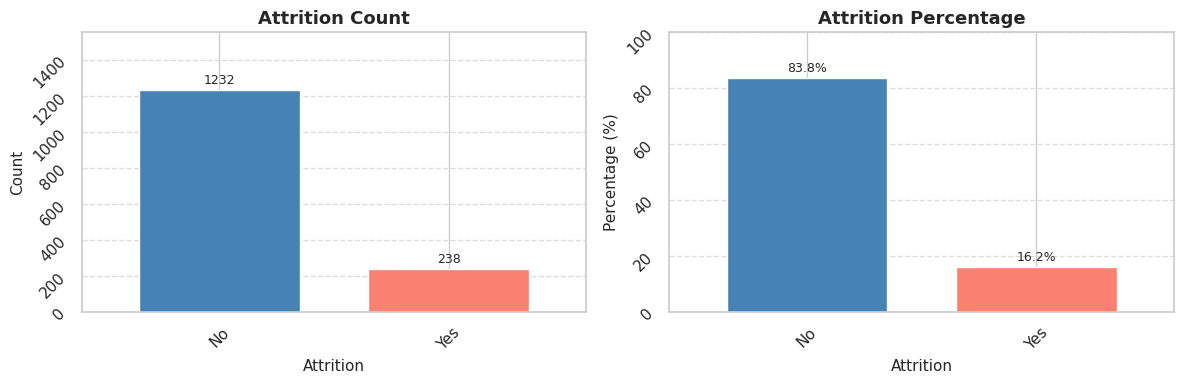

In [17]:
attrition = dataset['Attrition'].value_counts()
attrition_percentage = dataset['Attrition'].value_counts(normalize=True) * 100

fig, axes = plt.subplots(1, 2, figsize=(12, 4), sharey=False)
#  basing on the numbers
attrition.plot(kind='bar', ax=axes[0], color=['steelblue', 'salmon'], width=0.7)
for container in axes[0].containers:
    axes[0].bar_label(container, fmt='%d', label_type='edge', fontsize=9, padding=2)
axes[0].set_title('Attrition Count', fontsize=13, fontweight='bold')
axes[0].set_xlabel('Attrition', fontsize=11)
axes[0].set_ylabel('Count', fontsize=11)
axes[0].grid(axis='y', linestyle='--', alpha=0.7)
axes[0].set_ylim(0, axes[0].get_ylim()[1] * 1.2)
axes[0].tick_params(axis='x', rotation=45)
axes[0].tick_params(axis='y', rotation=45)
# basing on the percentage
attrition_percentage.plot(kind='bar', ax=axes[1], color=['steelblue', 'salmon'], width=0.7)
for container in axes[1].containers:
    axes[1].bar_label(container, fmt='%.1f%%', label_type='edge', fontsize=9, padding=2)
axes[1].set_title('Attrition Percentage', fontsize=13, fontweight='bold')
axes[1].set_xlabel('Attrition', fontsize=11)
axes[1].set_ylabel('Percentage (%)', fontsize=11)
axes[1].grid(axis='y', linestyle='--', alpha=0.7)
axes[1].set_ylim(0, 100)
axes[1].tick_params(axis='x', rotation=45)
axes[1].tick_params(axis='y', rotation=45)

plt.tight_layout()
plt.show()

Followig graghs  reveal who is more likely to leave(attrition) — based on characteristics like age, gender, marital status, education, education field and overtime .

These attributes help identify turnover patterns that are not directly related to job roles, compensation, or performance but may reflect lifestyle stages or career goals.


### Depending on Age

In [18]:
mean_age_by_attrition = dataset.groupby('Attrition')['Age'].mean()
# calculating the mean Age of those with attrition of Yes
age_attrition_yes = dataset.loc[dataset['Attrition'] == 'Yes', 'Age']
mean_age_attrition_yes = age_attrition_yes.mean()
# calculating the mean Age of those with attrition of No
age_attrition_no  = dataset.loc[dataset['Attrition'] == 'No',  'Age']
mean_age_attrition_no = age_attrition_no.mean()

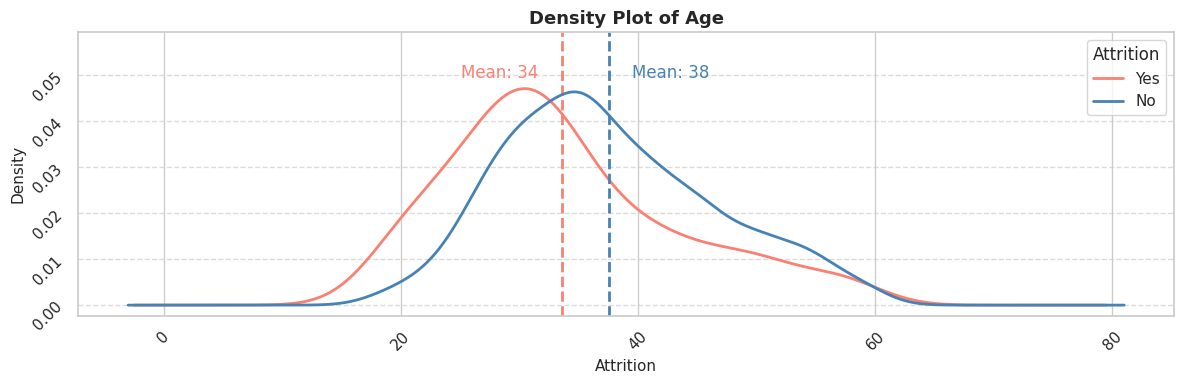

In [19]:
fig, axes = plt.subplots(figsize=(12, 4), sharey=False)

age_attrition_yes.plot(kind='kde', ax=axes, color='salmon', linewidth=2, label='Yes')
axes.axvline(mean_age_attrition_yes, color='salmon', linestyle='--', linewidth=2)
axes.text(mean_age_attrition_yes - 2, plt.ylim()[1], f'Mean: {mean_age_attrition_yes:.0f}',color='salmon', ha='right')

age_attrition_no.plot(kind='kde', ax=axes, color='steelblue', linewidth=2, label='No')
axes.axvline(mean_age_attrition_no, color='steelblue', linestyle='--', linewidth=2)
axes.text(mean_age_attrition_no + 2, plt.ylim()[1], f'Mean: {mean_age_attrition_no:.0f}',color='steelblue')

axes.set_title('Density Plot of Age', fontsize=13, fontweight='bold')
axes.set_xlabel('Attrition', fontsize=11)
axes.set_ylabel('Density', fontsize=11)
axes.set_ylim(axes.get_ylim()[0], axes.get_ylim()[1] * 1.2)
axes.grid(axis='y', linestyle='--', alpha=0.7)
axes.tick_params(axis='x', rotation=45)
axes.tick_params(axis='y', rotation=45)
axes.legend(title='Attrition')

plt.tight_layout()
plt.show()

### Depending by Gender

In [20]:
# Overall Gender Distribution
gender_count = dataset['Gender'].value_counts()
gender_count_by_attrition = pd.crosstab(dataset['Gender'], dataset['Attrition'])

#Attrition Breakdown by Gender
gender_percentage = dataset['Gender'].value_counts(normalize=True) * 100
gender_percentage_by_attrition = pd.crosstab(dataset['Gender'], dataset['Attrition'], normalize=True) * 100

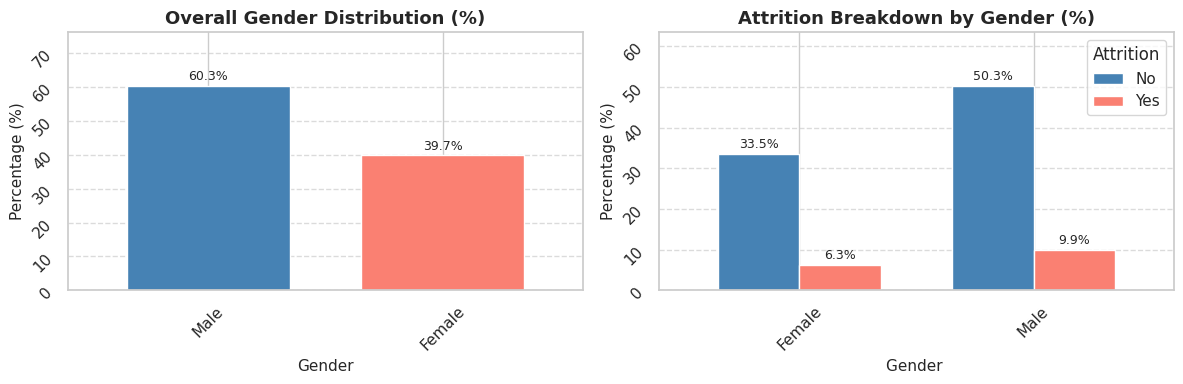

In [21]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4), sharey=False)

gender_percentage.plot(kind='bar', ax=axes[0], color=['steelblue', 'salmon'], width=0.7)
for container in axes[0].containers:
    axes[0].bar_label(container, fmt='%.1f%%', label_type='edge', fontsize=9, padding=2)
axes[0].set_title('Overall Gender Distribution (%)', fontsize=13, fontweight='bold')
axes[0].set_xlabel('Gender', fontsize=11)
axes[0].set_ylabel('Percentage (%)', fontsize=11)
axes[0].grid(axis='y', linestyle='--', alpha=0.7)
axes[0].set_ylim(0, axes[0].get_ylim()[1] * 1.2)
axes[0].tick_params(axis='x', rotation=45)
axes[0].tick_params(axis='y', rotation=45)

gender_percentage_by_attrition.plot(kind='bar', ax=axes[1], color=['steelblue', 'salmon'], width=0.7)
for container in axes[1].containers:
    axes[1].bar_label(container, fmt='%.1f%%', label_type='edge', fontsize=9, padding=2)
axes[1].set_title('Attrition Breakdown by Gender (%)', fontsize=13, fontweight='bold')
axes[1].set_xlabel('Gender ', fontsize=11)
axes[1].set_ylabel('Percentage (%)', fontsize=11)
axes[1].grid(axis='y', linestyle='--', alpha=0.7)
axes[1].set_ylim(0, axes[1].get_ylim()[1] * 1.2)
axes[1].tick_params(axis='x', rotation=45)
axes[1].tick_params(axis='y', rotation=45)

plt.tight_layout()
plt.show()

### Depending On Marital Status(Whether they are married or not )

In [22]:
marital_status_count = dataset['MaritalStatus'].value_counts()
marital_status_percentage = dataset['MaritalStatus'].value_counts(normalize=True) * 100
marital_status_count_by_attrition = pd.crosstab(dataset['MaritalStatus'], dataset['Attrition'])
marital_status_percentage_by_attrition = pd.crosstab(dataset['MaritalStatus'], dataset['Attrition'], normalize=True) * 100

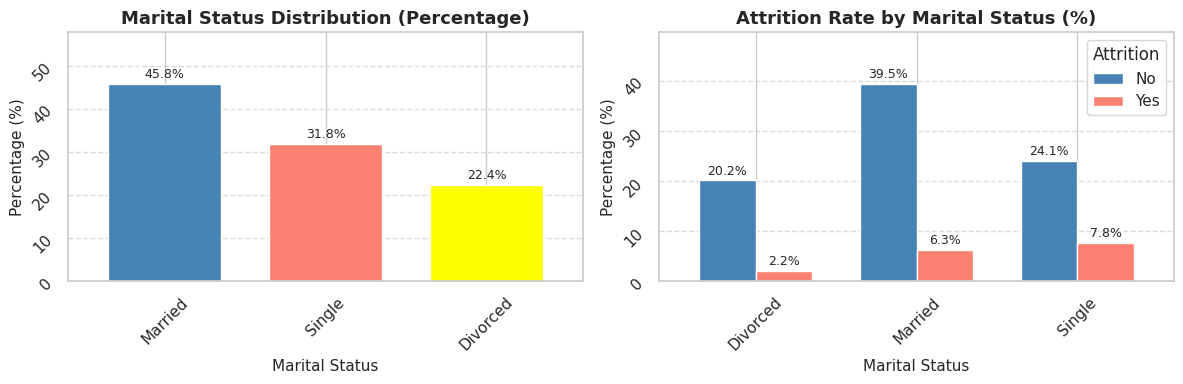

In [23]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4), sharey=False)

marital_status_percentage.plot(kind='bar', ax=axes[0], color=['steelblue', 'salmon', 'yellow'], width=0.7)
for container in axes[0].containers:
    axes[0].bar_label(container, fmt='%.1f%%', label_type='edge', fontsize=9, padding=2)
axes[0].set_title('Marital Status Distribution (Percentage)', fontsize=13, fontweight='bold')
axes[0].set_xlabel('Marital Status', fontsize=11)
axes[0].set_ylabel('Percentage (%)', fontsize=11)
axes[0].grid(axis='y', linestyle='--', alpha=0.7)
axes[0].set_ylim(0, axes[0].get_ylim()[1] * 1.2)
axes[0].tick_params(axis='x', rotation=45)
axes[0].tick_params(axis='y', rotation=45)

marital_status_percentage_by_attrition.plot(kind='bar', ax=axes[1], color=['steelblue', 'salmon'], width=0.7)
for container in axes[1].containers:
    axes[1].bar_label(container, fmt='%.1f%%', label_type='edge', fontsize=9, padding=2)
axes[1].set_title('Attrition Rate by Marital Status (%)', fontsize=13, fontweight='bold')
axes[1].set_xlabel('Marital Status', fontsize=11)
axes[1].set_ylabel('Percentage (%)', fontsize=11)
axes[1].grid(axis='y', linestyle='--', alpha=0.7)
axes[1].set_ylim(0, axes[1].get_ylim()[1] * 1.2)
axes[1].tick_params(axis='x', rotation=45)
axes[1].tick_params(axis='y', rotation=45)

plt.tight_layout()
plt.show()

### Depending on Education

In [24]:
education_level_count = dataset['Education'].value_counts()
education_level_count_by_attrition = pd.crosstab(dataset['Education'], dataset['Attrition'])

education_level_percentage = dataset['Education'].value_counts(normalize=True) * 100
education_level_percentage_by_attrition = pd.crosstab(dataset['Education'], dataset['Attrition'], normalize=True) * 100

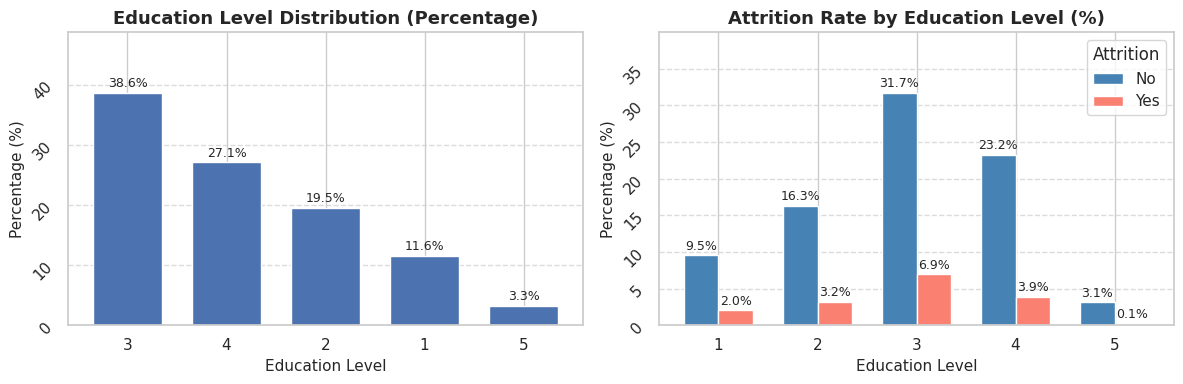

In [25]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4), sharey=False)

education_level_percentage.plot(kind='bar', ax=axes[0], width=0.7)
for container in axes[0].containers:
    axes[0].bar_label(container, fmt='%.1f%%', label_type='edge', fontsize=9, padding=2)
axes[0].set_title('Education Level Distribution (Percentage)', fontsize=13, fontweight='bold')
axes[0].set_xlabel('Education Level', fontsize=11)
axes[0].set_ylabel('Percentage (%)', fontsize=11)
axes[0].grid(axis='y', linestyle='--', alpha=0.7)
axes[0].set_ylim(0, axes[0].get_ylim()[1] * 1.2)
axes[0].tick_params(axis='x', rotation=0)
axes[0].tick_params(axis='y', rotation=45)

education_level_percentage_by_attrition.plot(kind='bar', ax=axes[1], color=['steelblue', 'salmon'], width=0.7)
for container in axes[1].containers:
    axes[1].bar_label(container, fmt='%.1f%%', label_type='edge', fontsize=9, padding=2)
axes[1].set_title('Attrition Rate by Education Level (%)', fontsize=13, fontweight='bold')
axes[1].set_xlabel('Education Level', fontsize=11)
axes[1].set_ylabel('Percentage (%)', fontsize=11)
axes[1].grid(axis='y', linestyle='--', alpha=0.7)
axes[1].set_ylim(0, axes[1].get_ylim()[1] * 1.2)
axes[1].tick_params(axis='x', rotation=0)
axes[1].tick_params(axis='y', rotation=45)

plt.tight_layout()
plt.show()

### Depending on Education Field

In [26]:
education_field_count = dataset['EducationField'].value_counts()
education_field_count_by_attrition = pd.crosstab(dataset['EducationField'], dataset['Attrition'])

education_field_percentage = dataset['EducationField'].value_counts(normalize=True) * 100
education_field_percentage_by_attrition = pd.crosstab(dataset['EducationField'], dataset['Attrition'], normalize=True) * 100

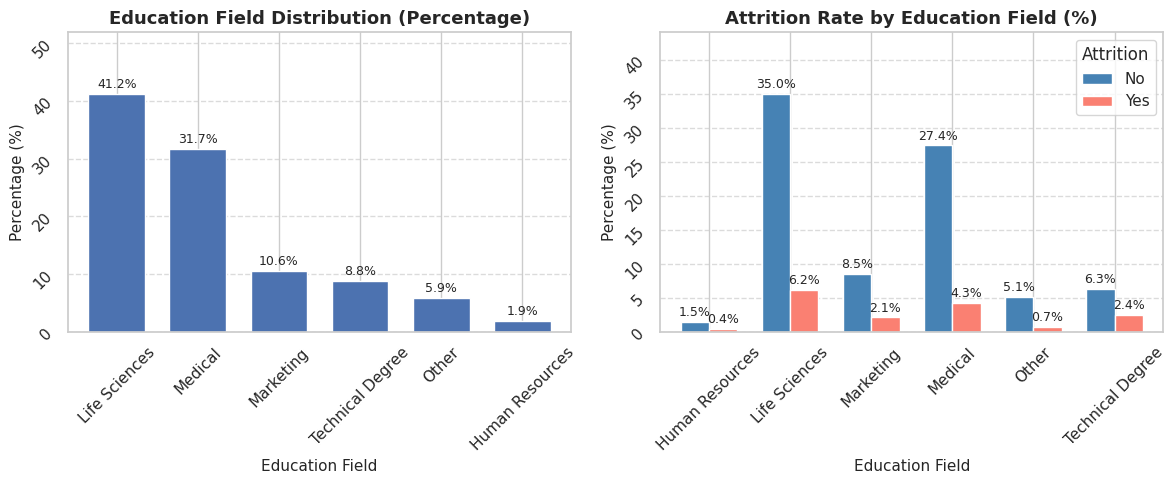

In [27]:
fig, axes = plt.subplots(1, 2, figsize=(12, 5), sharey=False)

education_field_percentage.plot(kind='bar', ax=axes[0], width=0.7)
for container in axes[0].containers:
    axes[0].bar_label(container, fmt='%.1f%%', label_type='edge', fontsize=9, padding=2)
axes[0].set_title('Education Field Distribution (Percentage)', fontsize=13, fontweight='bold')
axes[0].set_xlabel('Education Field', fontsize=11)
axes[0].set_ylabel('Percentage (%)', fontsize=11)
axes[0].grid(axis='y', linestyle='--', alpha=0.7)
axes[0].set_ylim(0, axes[0].get_ylim()[1] * 1.2)
axes[0].tick_params(axis='x', rotation=45)
axes[0].tick_params(axis='y', rotation=45)

education_field_percentage_by_attrition.plot(kind='bar', ax=axes[1], color=['steelblue', 'salmon'], width=0.7)
for container in axes[1].containers:
    axes[1].bar_label(container, fmt='%.1f%%', label_type='edge', fontsize=9, padding=2)
axes[1].set_title('Attrition Rate by Education Field (%)', fontsize=13, fontweight='bold')
axes[1].set_xlabel('Education Field', fontsize=11)
axes[1].set_ylabel('Percentage (%)', fontsize=11)
axes[1].grid(axis='y', linestyle='--', alpha=0.7)
axes[1].set_ylim(0, axes[1].get_ylim()[1] * 1.2)
axes[1].tick_params(axis='x', rotation=45)
axes[1].tick_params(axis='y', rotation=45)

plt.tight_layout()
plt.show()

### Depending On Overtime

In [28]:
overtime_count = dataset['OverTime'].value_counts()
overtime_count_by_attrition = pd.crosstab(dataset['OverTime'], dataset['Attrition'])

overtime_percentage = dataset['OverTime'].value_counts(normalize=True) * 100
overtime_percentage_by_attrition = pd.crosstab(dataset['OverTime'], dataset['Attrition'], normalize=True) * 100

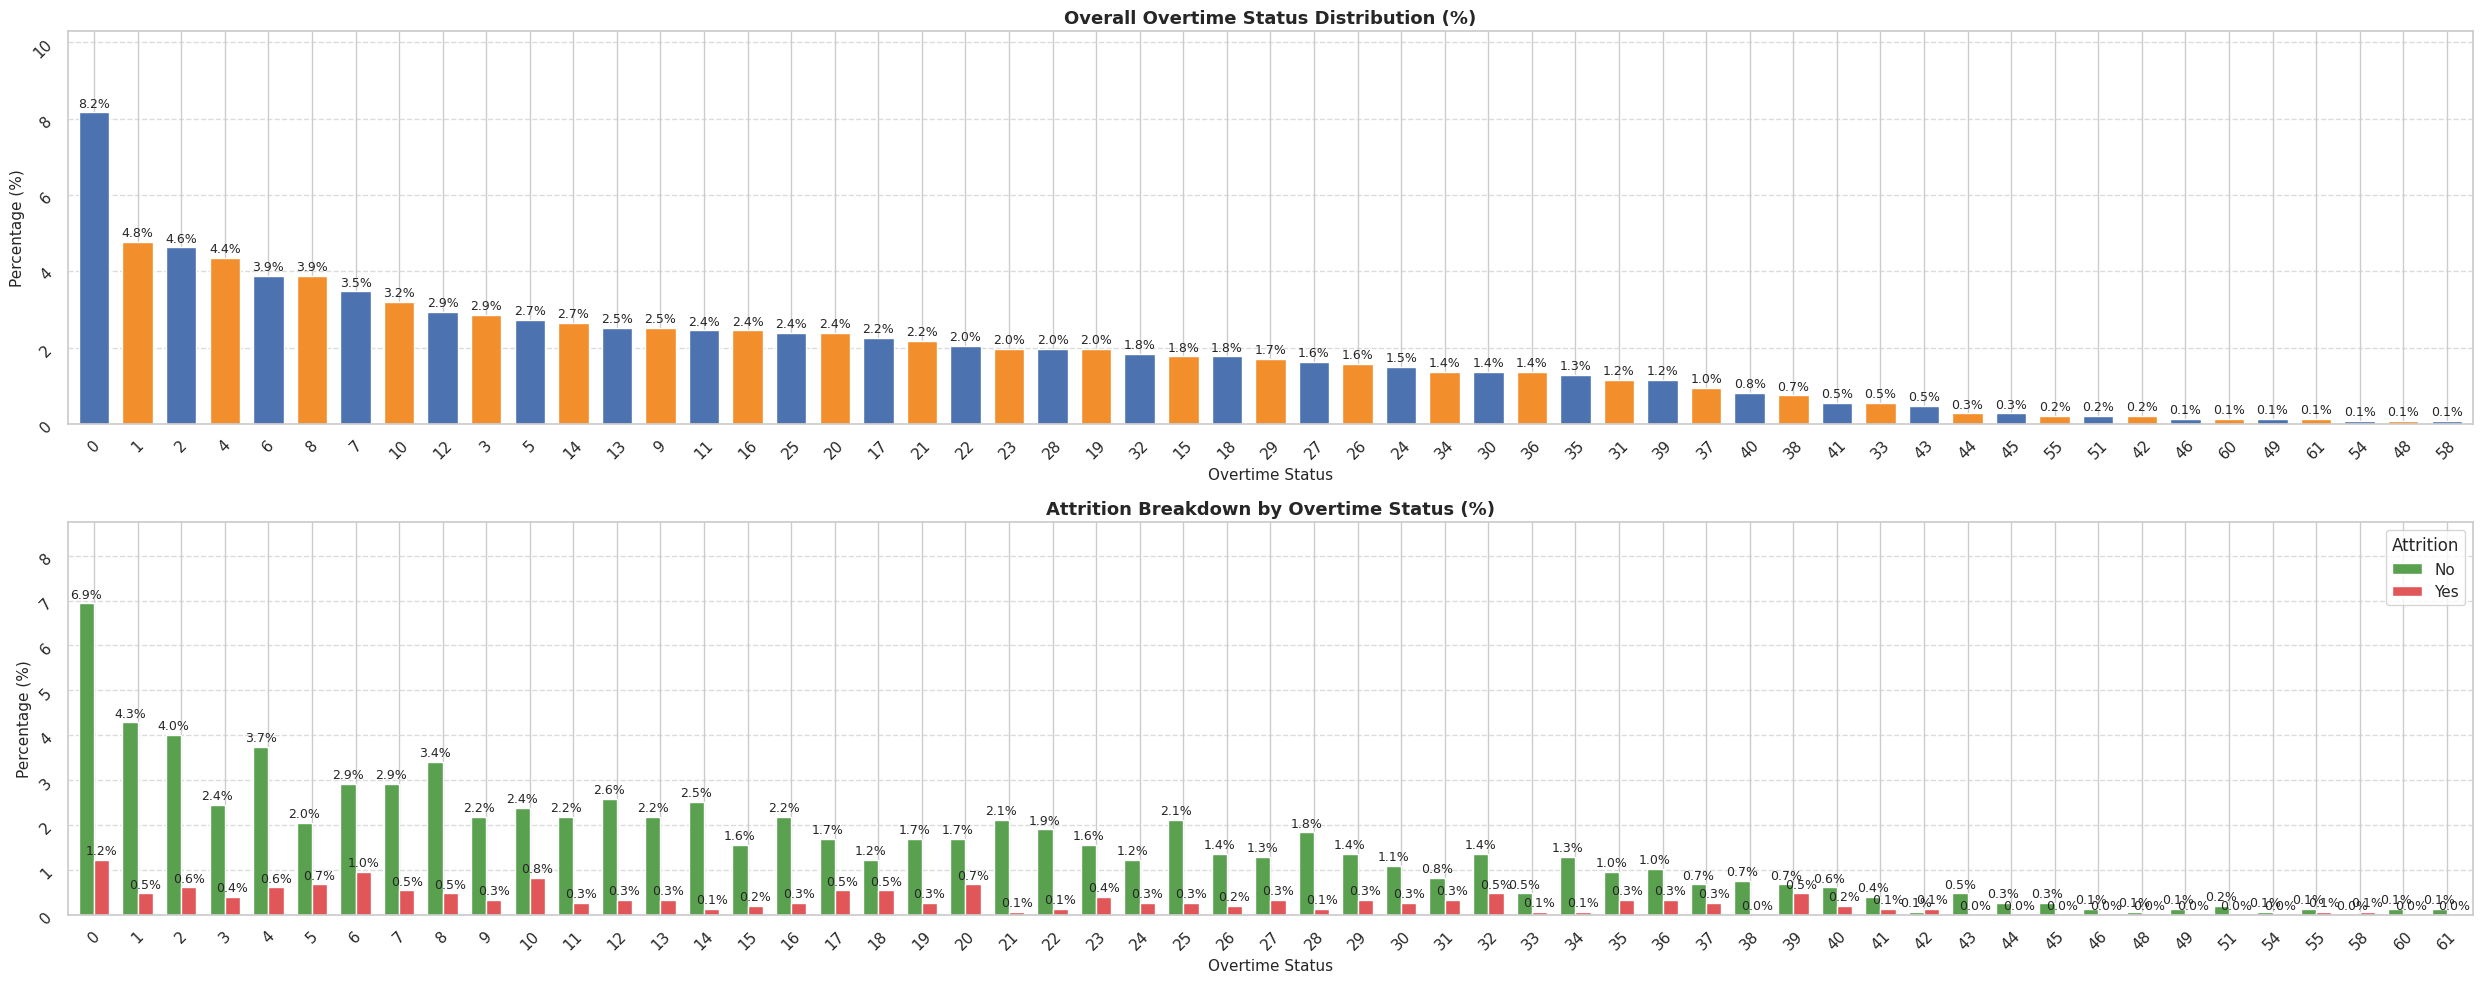

In [29]:
fig, axes = plt.subplots( 2, figsize=(25, 10), sharey=False)

overtime_percentage.plot(kind='bar', ax=axes[0], color=['#4C72B0', '#F28E2B'] , width=0.7)
for container in axes[0].containers:
    axes[0].bar_label(container, fmt='%.1f%%', label_type='edge', fontsize=9, padding=2)
axes[0].set_title('Overall Overtime Status Distribution (%)', fontsize=13, fontweight='bold')
axes[0].set_xlabel('Overtime Status', fontsize=11)
axes[0].set_ylabel('Percentage (%)', fontsize=11)
axes[0].grid(axis='y', linestyle='--', alpha=0.7)
axes[0].set_ylim(0, axes[0].get_ylim()[1] * 1.2)
axes[0].tick_params(axis='x', rotation=45)
axes[0].tick_params(axis='y', rotation=45)

overtime_percentage_by_attrition.plot(kind='bar', ax=axes[1], color=['#59A14F', '#E15759'], width=0.7)
for container in axes[1].containers:
    axes[1].bar_label(container, fmt='%.1f%%', label_type='edge', fontsize=9, padding=2)
axes[1].set_title('Attrition Breakdown by Overtime Status (%)', fontsize=13, fontweight='bold')
axes[1].set_xlabel('Overtime Status', fontsize=11)
axes[1].set_ylabel('Percentage (%)', fontsize=11)
axes[1].grid(axis='y', linestyle='--', alpha=0.7)
axes[1].set_ylim(0, axes[1].get_ylim()[1] * 1.2)
axes[1].tick_params(axis='x', rotation=45)
axes[1].tick_params(axis='y', rotation=45)

plt.tight_layout()
plt.show()

### Depending on WorkLife Balance

In [30]:
wlb_count = dataset['WorkLifeBalance'].value_counts()
wlb_count_by_attrition = pd.crosstab(dataset['WorkLifeBalance'], dataset['Attrition'])

wlb_percentage = dataset['WorkLifeBalance'].value_counts(normalize=True) * 100
wlb_percentage_by_attrition = pd.crosstab(dataset['WorkLifeBalance'], dataset['Attrition'], normalize=True) * 100

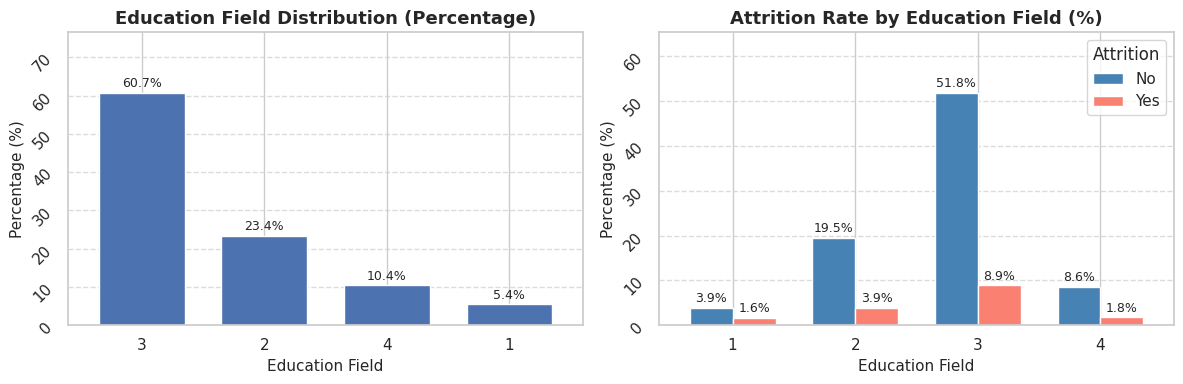

In [31]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4), sharey=False)

wlb_percentage.plot(kind='bar', ax=axes[0], width=0.7)
for container in axes[0].containers:
    axes[0].bar_label(container, fmt='%.1f%%', label_type='edge', fontsize=9, padding=2)
axes[0].set_title('Education Field Distribution (Percentage)', fontsize=13, fontweight='bold')
axes[0].set_xlabel('Education Field', fontsize=11)
axes[0].set_ylabel('Percentage (%)', fontsize=11)
axes[0].grid(axis='y', linestyle='--', alpha=0.7)
axes[0].set_ylim(0, axes[0].get_ylim()[1] * 1.2)
axes[0].tick_params(axis='x', rotation=0)
axes[0].tick_params(axis='y', rotation=45)

wlb_percentage_by_attrition.plot(kind='bar', ax=axes[1], color=['steelblue', 'salmon'], width=0.7)
for container in axes[1].containers:
    axes[1].bar_label(container, fmt='%.1f%%', label_type='edge', fontsize=9, padding=2)
axes[1].set_title('Attrition Rate by Education Field (%)', fontsize=13, fontweight='bold')
axes[1].set_xlabel('Education Field', fontsize=11)
axes[1].set_ylabel('Percentage (%)', fontsize=11)
axes[1].grid(axis='y', linestyle='--', alpha=0.7)
axes[1].set_ylim(0, axes[1].get_ylim()[1] * 1.2)
axes[1].tick_params(axis='x', rotation=0)
axes[1].tick_params(axis='y', rotation=45)

plt.tight_layout()
plt.show()


### Depending on Job Involvement

In [32]:
jobinv_count = dataset['JobInvolvement'].value_counts()
jobinv_count_by_attrition = pd.crosstab(dataset['JobInvolvement'], dataset['Attrition'])

jobinv_percentage = dataset['JobInvolvement'].value_counts(normalize=True) * 100
jobinv_percentage_by_attrition = pd.crosstab(dataset['JobInvolvement'], dataset['Attrition'], normalize=True) * 100

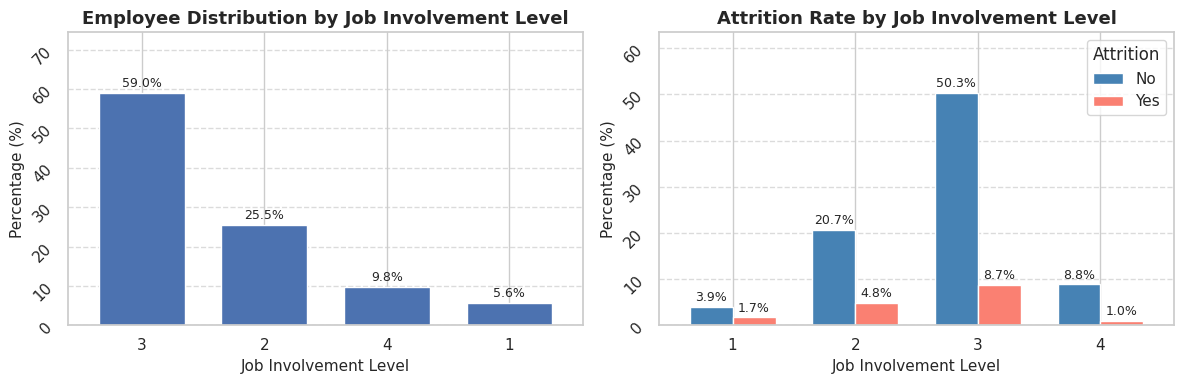

In [33]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4), sharey=False)

jobinv_percentage.plot(kind='bar', ax=axes[0], width=0.7)
for container in axes[0].containers:
    axes[0].bar_label(container, fmt='%.1f%%', label_type='edge', fontsize=9, padding=2)
axes[0].set_title('Employee Distribution by Job Involvement Level', fontsize=13, fontweight='bold')
axes[0].set_xlabel('Job Involvement Level', fontsize=11)
axes[0].set_ylabel('Percentage (%)', fontsize=11)
axes[0].grid(axis='y', linestyle='--', alpha=0.7)
axes[0].set_ylim(0, axes[0].get_ylim()[1] * 1.2)
axes[0].tick_params(axis='x', rotation=0)
axes[0].tick_params(axis='y', rotation=45)

jobinv_percentage_by_attrition.plot(kind='bar', ax=axes[1], color=['steelblue', 'salmon'], width=0.7)
for container in axes[1].containers:
    axes[1].bar_label(container, fmt='%.1f%%', label_type='edge', fontsize=9, padding=2)
axes[1].set_title('Attrition Rate by Job Involvement Level', fontsize=13, fontweight='bold')
axes[1].set_xlabel('Job Involvement Level', fontsize=11)
axes[1].set_ylabel('Percentage (%)', fontsize=11)
axes[1].grid(axis='y', linestyle='--', alpha=0.7)
axes[1].set_ylim(0, axes[1].get_ylim()[1] * 1.2)
axes[1].tick_params(axis='x', rotation=0)
axes[1].tick_params(axis='y', rotation=45)

plt.tight_layout()
plt.show()

### Depending on Envirnoment Satisfication

In [34]:
env_satisfaction_count = dataset['EnvironmentSatisfaction'].value_counts()
env_satisfaction_count_by_attrition = pd.crosstab(dataset['EnvironmentSatisfaction'], dataset['Attrition'])

env_satisfaction_percentage = dataset['EnvironmentSatisfaction'].value_counts(normalize=True) * 100
env_satisfaction_percentage_by_attrition = pd.crosstab(dataset['EnvironmentSatisfaction'], dataset['Attrition'], normalize=True) * 100

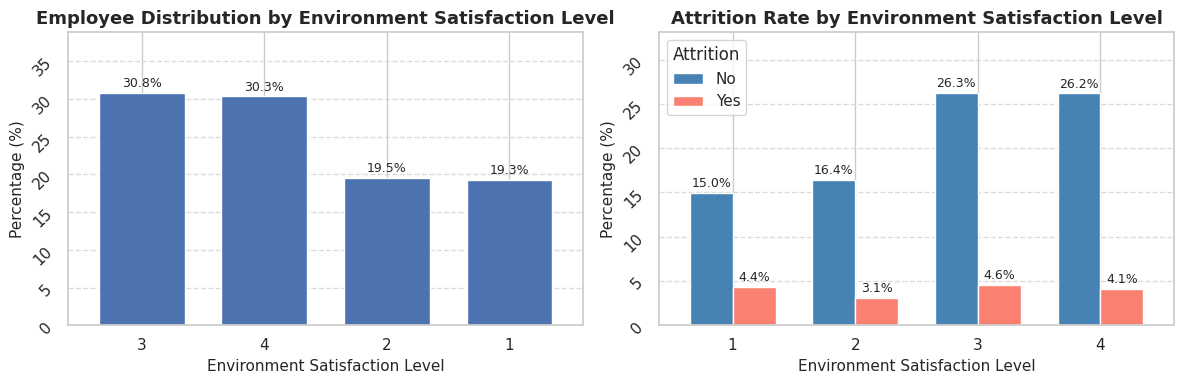

In [35]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4), sharey=False)

env_satisfaction_percentage.plot(kind='bar', ax=axes[0], width=0.7)
for container in axes[0].containers:
    axes[0].bar_label(container, fmt='%.1f%%', label_type='edge', fontsize=9, padding=2)
axes[0].set_title('Employee Distribution by Environment Satisfaction Level', fontsize=13, fontweight='bold')
axes[0].set_xlabel('Environment Satisfaction Level', fontsize=11)
axes[0].set_ylabel('Percentage (%)', fontsize=11)
axes[0].grid(axis='y', linestyle='--', alpha=0.7)
axes[0].set_ylim(0, axes[0].get_ylim()[1] * 1.2)
axes[0].tick_params(axis='x', rotation=0)
axes[0].tick_params(axis='y', rotation=45)

env_satisfaction_percentage_by_attrition.plot(kind='bar', ax=axes[1], color=['steelblue', 'salmon'], width=0.7)
for container in axes[1].containers:
    axes[1].bar_label(container, fmt='%.1f%%', label_type='edge', fontsize=9, padding=2)
axes[1].set_title('Attrition Rate by Environment Satisfaction Level', fontsize=13, fontweight='bold')
axes[1].set_xlabel('Environment Satisfaction Level', fontsize=11)
axes[1].set_ylabel('Percentage (%)', fontsize=11)
axes[1].grid(axis='y', linestyle='--', alpha=0.7)
axes[1].set_ylim(0, axes[1].get_ylim()[1] * 1.2)
axes[1].tick_params(axis='x', rotation=0)
axes[1].tick_params(axis='y', rotation=45)

plt.tight_layout()
plt.show()

### Depending On Job Satisfication

In [36]:
job_satisfaction_count = dataset['JobSatisfaction'].value_counts()
job_satisfaction_count_by_attrition = pd.crosstab(dataset['JobSatisfaction'], dataset['Attrition'])

job_satisfaction_percentage = dataset['JobSatisfaction'].value_counts(normalize=True) * 100
job_satisfaction_percentage_by_attrition = pd.crosstab(dataset['JobSatisfaction'], dataset['Attrition'], normalize=True) * 100

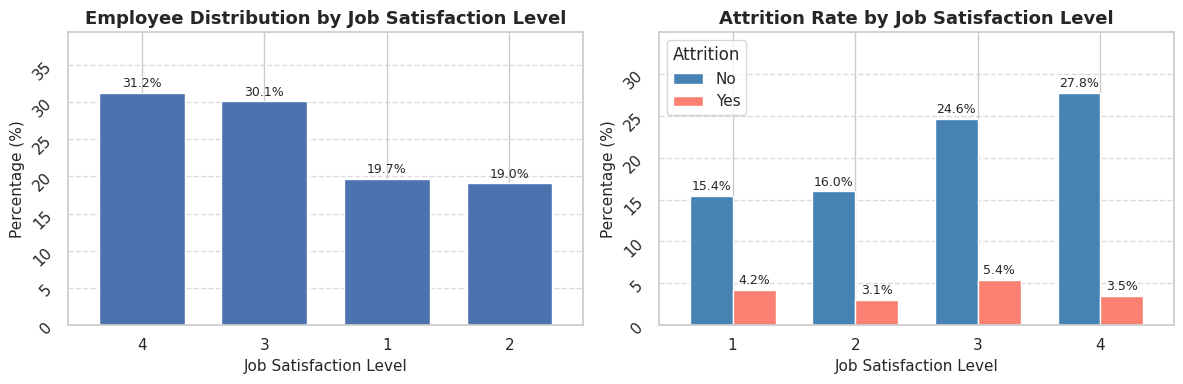

In [37]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4), sharey=False)

job_satisfaction_percentage.plot(kind='bar', ax=axes[0], width=0.7)
for container in axes[0].containers:
    axes[0].bar_label(container, fmt='%.1f%%', label_type='edge', fontsize=9, padding=2)
axes[0].set_title('Employee Distribution by Job Satisfaction Level', fontsize=13, fontweight='bold')
axes[0].set_xlabel('Job Satisfaction Level', fontsize=11)
axes[0].set_ylabel('Percentage (%)', fontsize=11)
axes[0].grid(axis='y', linestyle='--', alpha=0.7)
axes[0].set_ylim(0, axes[0].get_ylim()[1] * 1.2)
axes[0].tick_params(axis='x', rotation=0)
axes[0].tick_params(axis='y', rotation=45)

job_satisfaction_percentage_by_attrition.plot(kind='bar', ax=axes[1], color=['steelblue', 'salmon'], width=0.7)
for container in axes[1].containers:
    axes[1].bar_label(container, fmt='%.1f%%', label_type='edge', fontsize=9, padding=2)
axes[1].set_title('Attrition Rate by Job Satisfaction Level', fontsize=13, fontweight='bold')
axes[1].set_xlabel('Job Satisfaction Level', fontsize=11)
axes[1].set_ylabel('Percentage (%)', fontsize=11)
axes[1].grid(axis='y', linestyle='--', alpha=0.7)
axes[1].set_ylim(0, axes[1].get_ylim()[1] * 1.2)
axes[1].tick_params(axis='x', rotation=0)
axes[1].tick_params(axis='y', rotation=45)

plt.tight_layout()
plt.show()

### Depending on Monthly Incmoe

In [38]:
median_income_by_attrition = dataset.groupby('Attrition')['MonthlyIncome'].median()

income_attrition_yes = dataset.loc[dataset['Attrition'] == 'Yes', 'MonthlyIncome']
mean_income_attrition_yes = income_attrition_yes.mean()
income_attrition_no  = dataset.loc[dataset['Attrition'] == 'No',  'MonthlyIncome']
mean_income_attrition_no = income_attrition_no.mean()

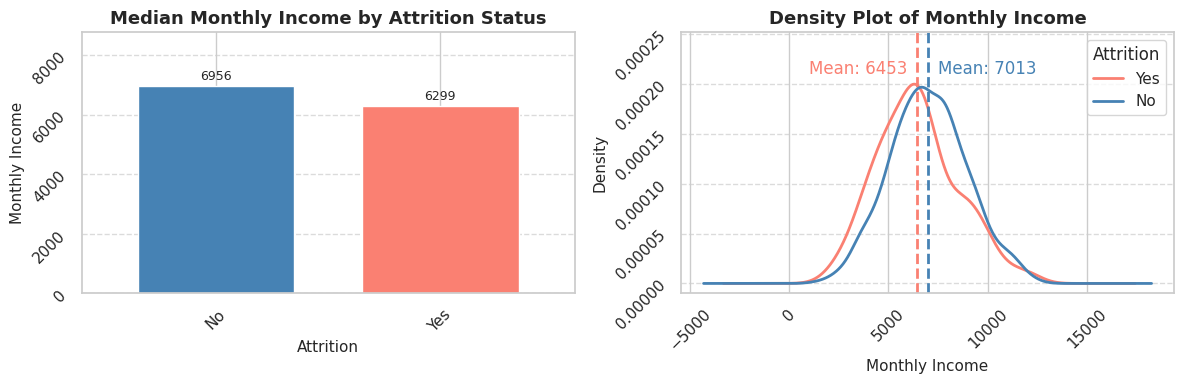

In [39]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4), sharey=False)

median_income_by_attrition.plot(kind='bar', color=['steelblue', 'salmon'], ax=axes[0], width=0.7)
for container in axes[0].containers:
    axes[0].bar_label(container, fmt='%d', label_type='edge', fontsize=9, padding=2)
axes[0].set_title('Median Monthly Income by Attrition Status', fontsize=13, fontweight='bold')
axes[0].set_xlabel('Attrition', fontsize=11)
axes[0].set_ylabel('Monthly Income', fontsize=11)
axes[0].set_ylim(0, axes[0].get_ylim()[1] * 1.2)
axes[0].grid(axis='y', linestyle='--', alpha=0.7)
axes[0].tick_params(axis='x', rotation=45)
axes[0].tick_params(axis='y', rotation=45)

income_attrition_yes.plot(kind='kde', ax=axes[1], color='salmon', linewidth=2, label='Yes')
axes[1].axvline(mean_income_attrition_yes, color='salmon', linestyle='--', linewidth=2)
axes[1].text(mean_income_attrition_yes - 500, plt.ylim()[1], f'Mean: {mean_income_attrition_yes:.0f}',color='salmon', ha='right')

income_attrition_no.plot(kind='kde', ax=axes[1], color='steelblue', linewidth=2, label='No')
axes[1].axvline(mean_income_attrition_no, color='steelblue', linestyle='--', linewidth=2)
axes[1].text(mean_income_attrition_no + 500, plt.ylim()[1], f'Mean: {mean_income_attrition_no:.0f}',color='steelblue')

axes[1].set_title('Density Plot of Monthly Income', fontsize=13, fontweight='bold')
axes[1].set_xlabel('Monthly Income', fontsize=11)
axes[1].set_ylabel('Density', fontsize=11)
axes[1].set_ylim(axes[1].get_ylim()[0], axes[1].get_ylim()[1] * 1.2)
axes[1].grid(axis='y', linestyle='--', alpha=0.7)
axes[1].tick_params(axis='x', rotation=45)
axes[1].tick_params(axis='y', rotation=45)
axes[1].legend(title='Attrition')

plt.tight_layout()
plt.show()


### Depending on Job Role

In [40]:
job_role = dataset['JobRole'].value_counts()
job_role_by_attrition = pd.crosstab(dataset['JobRole'], dataset['Attrition'])

job_role_percentage = dataset['JobRole'].value_counts(normalize=True) * 100
job_role_percentage_by_attrition = pd.crosstab(dataset['JobRole'], dataset['Attrition'], normalize=True) * 100

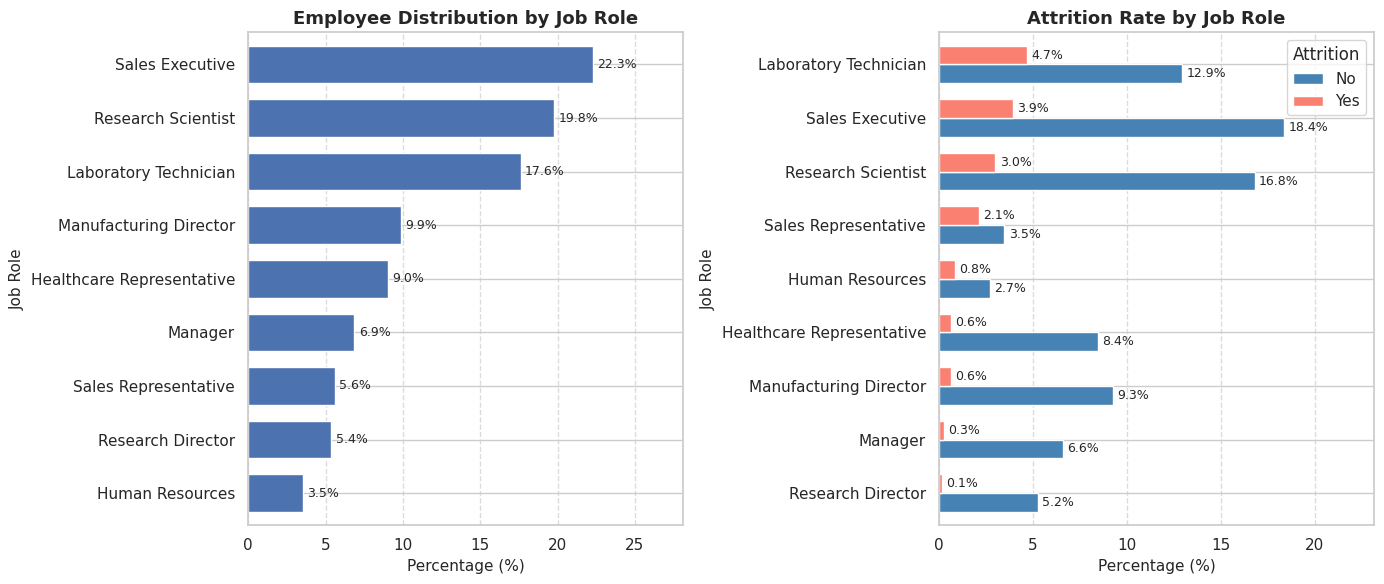

In [41]:
fig, axes = plt.subplots(1, 2, figsize=(14, 6), sharey=False)

job_role_percentage.sort_values().plot(
    kind='barh',
    ax=axes[0],
    width=0.7
)

for container in axes[0].containers:
    axes[0].bar_label(container, fmt='%.1f%%', fontsize=9, padding=3)

axes[0].set_title('Employee Distribution by Job Role', fontsize=13, fontweight='bold')
axes[0].set_xlabel('Percentage (%)', fontsize=11)
axes[0].set_ylabel('Job Role', fontsize=11)
axes[0].grid(axis='x', linestyle='--', alpha=0.7)
axes[0].set_xlim(0, axes[0].get_xlim()[1] * 1.2)

job_role_percentage_by_attrition.sort_values('Yes').plot(
    kind='barh',
    ax=axes[1],
    color=['steelblue', 'salmon'],
    width=0.7
)

for container in axes[1].containers:
    axes[1].bar_label(container, fmt='%.1f%%', fontsize=9, padding=3)

axes[1].set_title('Attrition Rate by Job Role', fontsize=13, fontweight='bold')
axes[1].set_xlabel('Percentage (%)', fontsize=11)
axes[1].set_ylabel('Job Role', fontsize=11)
axes[1].grid(axis='x', linestyle='--', alpha=0.7)
axes[1].set_xlim(0, axes[1].get_xlim()[1] * 1.2)

plt.tight_layout()
plt.show()

Depending on Business Travel

In [42]:
bussinee_travel_status = dataset['BusinessTravel'].value_counts()
bussinee_travel_status_by_attrition = pd.crosstab(dataset['BusinessTravel'], dataset['Attrition'])

bussinee_travel_status_percentage = dataset['BusinessTravel'].value_counts(normalize=True) * 100
bussinee_travel_status_percentage_by_attrition = pd.crosstab(dataset['BusinessTravel'], dataset['Attrition'], normalize=True) * 100

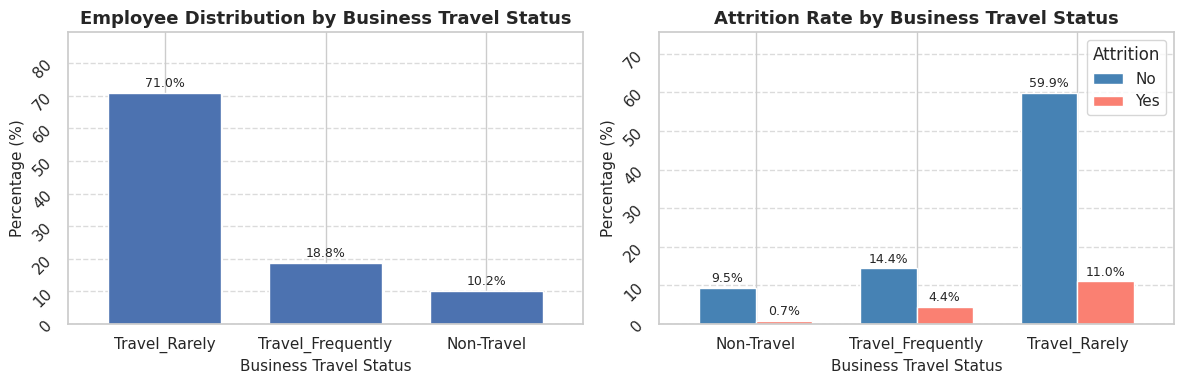

In [43]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4), sharey=False)

bussinee_travel_status_percentage.plot(kind='bar', ax=axes[0], width=0.7)
for container in axes[0].containers:
    axes[0].bar_label(container, fmt='%.1f%%', label_type='edge', fontsize=9, padding=2)
axes[0].set_title('Employee Distribution by Business Travel Status', fontsize=13, fontweight='bold')
axes[0].set_xlabel('Business Travel Status', fontsize=11)
axes[0].set_ylabel('Percentage (%)', fontsize=11)
axes[0].grid(axis='y', linestyle='--', alpha=0.7)
axes[0].set_ylim(0, axes[0].get_ylim()[1] * 1.2)
axes[0].tick_params(axis='x', rotation=0)
axes[0].tick_params(axis='y', rotation=45)

bussinee_travel_status_percentage_by_attrition.plot(kind='bar', ax=axes[1], color=['steelblue', 'salmon'], width=0.7)
for container in axes[1].containers:
    axes[1].bar_label(container, fmt='%.1f%%', label_type='edge', fontsize=9, padding=2)
axes[1].set_title('Attrition Rate by Business Travel Status', fontsize=13, fontweight='bold')
axes[1].set_xlabel('Business Travel Status', fontsize=11)
axes[1].set_ylabel('Percentage (%)', fontsize=11)
axes[1].grid(axis='y', linestyle='--', alpha=0.7)
axes[1].set_ylim(0, axes[1].get_ylim()[1] * 1.2)
axes[1].tick_params(axis='x', rotation=0)
axes[1].tick_params(axis='y', rotation=45)

plt.tight_layout()
plt.show()


### Depending on 	WelfareBenefits

In [44]:
welfare_benefits_status = dataset['WelfareBenefits'].value_counts()
welfare_benefits_status_by_attrition = pd.crosstab(dataset['WelfareBenefits'], dataset['Attrition'])

welfare_benefits_status_percentage = dataset['WelfareBenefits'].value_counts(normalize=True) * 100
welfare_benefits_status_percentage_by_attrition = pd.crosstab(dataset['WelfareBenefits'], dataset['Attrition'], normalize=True) * 100

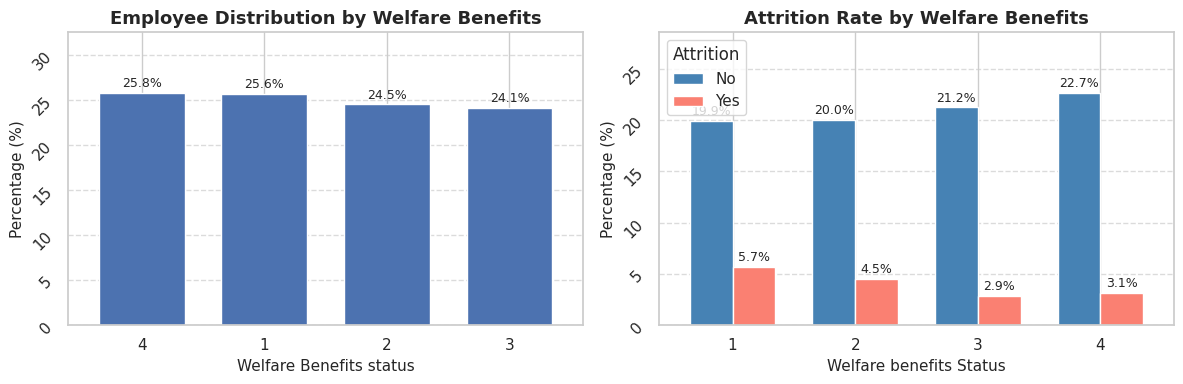

In [45]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4), sharey=False)

welfare_benefits_status_percentage.plot(kind='bar', ax=axes[0], width=0.7)
for container in axes[0].containers:
    axes[0].bar_label(container, fmt='%.1f%%', label_type='edge', fontsize=9, padding=2)
axes[0].set_title('Employee Distribution by Welfare Benefits', fontsize=13, fontweight='bold')
axes[0].set_xlabel('Welfare Benefits status', fontsize=11)
axes[0].set_ylabel('Percentage (%)', fontsize=11)
axes[0].grid(axis='y', linestyle='--', alpha=0.7)
axes[0].set_ylim(0, axes[0].get_ylim()[1] * 1.2)
axes[0].tick_params(axis='x', rotation=0)
axes[0].tick_params(axis='y', rotation=45)

welfare_benefits_status_percentage_by_attrition.plot(kind='bar', ax=axes[1], color=['steelblue', 'salmon'], width=0.7)
for container in axes[1].containers:
    axes[1].bar_label(container, fmt='%.1f%%', label_type='edge', fontsize=9, padding=2)
axes[1].set_title('Attrition Rate by Welfare Benefits', fontsize=13, fontweight='bold')
axes[1].set_xlabel('Welfare benefits Status', fontsize=11)
axes[1].set_ylabel('Percentage (%)', fontsize=11)
axes[1].grid(axis='y', linestyle='--', alpha=0.7)
axes[1].set_ylim(0, axes[1].get_ylim()[1] * 1.2)
axes[1].tick_params(axis='x', rotation=0)
axes[1].tick_params(axis='y', rotation=45)

plt.tight_layout()
plt.show()


## Depending on How Employees were Employed

In [46]:
How_to_employ_status = dataset['HowToEmploy'].value_counts()
How_to_employ_status_by_attrition = pd.crosstab(dataset['HowToEmploy'], dataset['Attrition'])

How_to_employ_status_percentage = dataset['HowToEmploy'].value_counts(normalize=True) * 100
How_to_employ_status_percentage_by_attrition = pd.crosstab(dataset['HowToEmploy'], dataset['Attrition'], normalize=True) * 100


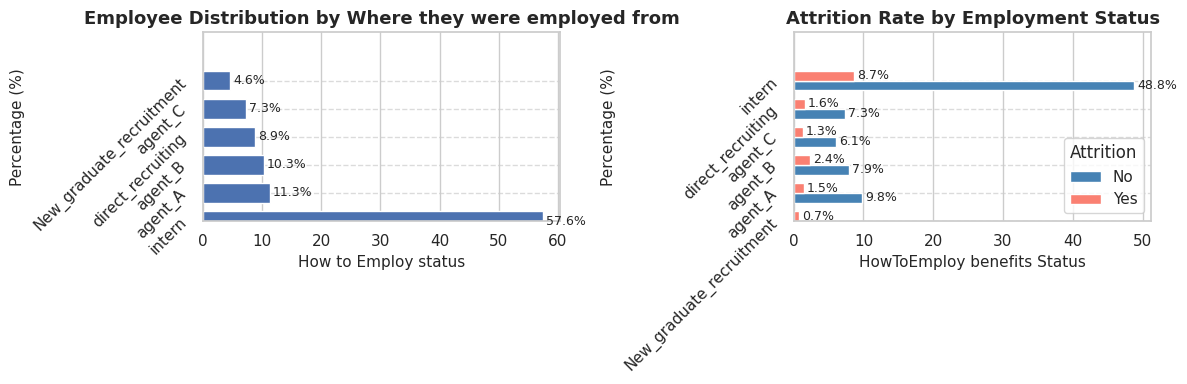

In [47]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4), sharey=False)

How_to_employ_status_percentage.plot(kind='barh', ax=axes[0], width=0.7)
for container in axes[0].containers:
    axes[0].bar_label(container, fmt='%.1f%%', label_type='edge', fontsize=9, padding=2)
axes[0].set_title('Employee Distribution by Where they were employed from', fontsize=13, fontweight='bold')
axes[0].set_xlabel('How to Employ status', fontsize=11)
axes[0].set_ylabel('Percentage (%)', fontsize=11)
axes[0].grid(axis='y', linestyle='--', alpha=0.7)
axes[0].set_ylim(0, axes[0].get_ylim()[1] * 1.2)
axes[0].tick_params(axis='x', rotation=0)
axes[0].tick_params(axis='y', rotation=45)

How_to_employ_status_percentage_by_attrition.plot(kind='barh', ax=axes[1], color=['steelblue', 'salmon'], width=0.7)
for container in axes[1].containers:
    axes[1].bar_label(container, fmt='%.1f%%', label_type='edge', fontsize=9, padding=2)
axes[1].set_title('Attrition Rate by Employment Status', fontsize=13, fontweight='bold')
axes[1].set_xlabel('HowToEmploy benefits Status', fontsize=11)
axes[1].set_ylabel('Percentage (%)', fontsize=11)
axes[1].grid(axis='y', linestyle='--', alpha=0.7)
axes[1].set_ylim(0, axes[1].get_ylim()[1] * 1.2)
axes[1].tick_params(axis='x', rotation=0)
axes[1].tick_params(axis='y', rotation=45)

plt.tight_layout()
plt.show()


## **Explanatory Data Analysis**

In [48]:
# Check dataset shape
print(f"The dataset has {dataset.shape[0]} rows and {dataset.shape[1]} columns.")

# Check data types and missing values
print("\nDataset Info:")
dataset.info()

The dataset has 1470 rows and 44 columns.

Dataset Info:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1470 entries, 0 to 1469
Data columns (total 44 columns):
 #   Column                    Non-Null Count  Dtype 
---  ------                    --------------  ----- 
 0   Age                       1470 non-null   int64 
 1   Attrition                 1470 non-null   object
 2   BusinessTravel            1470 non-null   object
 3   Department                1470 non-null   object
 4   DistanceFromHome          1470 non-null   int64 
 5   Education                 1470 non-null   int64 
 6   EducationField            1470 non-null   object
 7   EmployeeCount             1470 non-null   int64 
 8   EnvironmentSatisfaction   1470 non-null   int64 
 9   Gender                    1470 non-null   object
 10  PerformanceIndex          1470 non-null   int64 
 11  JobInvolvement            1470 non-null   int64 
 12  JobLevel                  1470 non-null   int64 
 13  JobRole              

# Model Training and Build

Based on Tutorial notebook I am going to train LightGBM for the model building and traing 60% of the data and test with 40% of the dats

In [49]:
from scipy.stats import randint, uniform


In [50]:
# Copy dataset to avoid overwriting accidentally
df = dataset.copy()

# Label encode all object columns
label_encoders = {}
for col in df.select_dtypes(include=['object']).columns:
    le = LabelEncoder()
    df[col] = le.fit_transform(df[col])
    label_encoders[col] = le


# Split Data
X = df.drop(['Attrition','EmployeeCount', 'Over18', 'StandardHours'], axis=1)
y = df['Attrition']


X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.4, random_state=42, stratify=y)

# Initialize LightGBM Dataset
train_data = lgb.Dataset(X_train, label=y_train)
test_data = lgb.Dataset(X_test, label=y_test, reference=train_data)

# Parameters
params = {
    'objective': 'binary',
    'metric': 'auc',
    'boosting_type': 'gbdt',
    'num_leaves': 31,
    'learning_rate': 0.05,
    'feature_fraction': 0.9,
    'verbose': -1,
    'is_unbalance': True # Handle class imbalance
}

# Train Model
lgb_model = lgb.train(
    params,
    train_data,
    num_boost_round=100,
    valid_sets=[test_data],
    callbacks=[lgb.early_stopping(stopping_rounds=10), lgb.log_evaluation(period=0)]
)

# Predictions
y_pred_proba = lgb_model.predict(X_test, num_iteration=lgb_model.best_iteration)

thresh = 0.5
y_pred = (y_pred_proba > thresh).astype(int)
f1 = f1_score(y_test, y_pred)

print(f"F1 Score: {f1:.4f}")

Training until validation scores don't improve for 10 rounds
Early stopping, best iteration is:
[76]	valid_0's auc: 0.799552
F1 Score: 0.4970


ROC-AUC; Accuracy and F1 SCore


As per the tutorial notebook

Accuracy: 0.8554421768707483
ROC-AUC: 0.7995516173801643

Classification Report:
               precision    recall  f1-score   support

           0       0.90      0.94      0.92       493
           1       0.57      0.44      0.50        95

    accuracy                           0.86       588
   macro avg       0.73      0.69      0.71       588
weighted avg       0.84      0.86      0.85       588



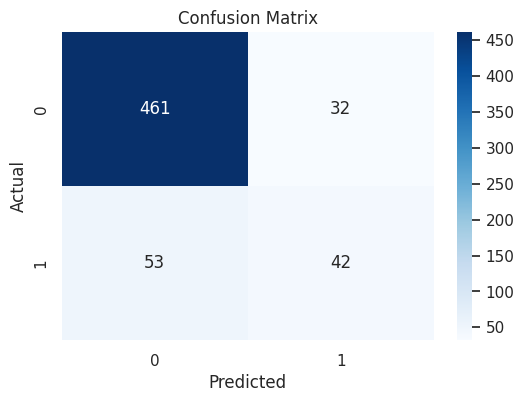

In [51]:
print("Accuracy:", accuracy_score(y_test, y_pred))
print("ROC-AUC:", roc_auc_score(y_test, y_pred_proba))
print("\nClassification Report:\n", classification_report(y_test, y_pred))

# Confusion Matrix
plt.figure(figsize=(6, 4))
sns.heatmap(confusion_matrix(y_test, y_pred), annot=True, fmt='d', cmap='Blues')
plt.title('Confusion Matrix')
plt.ylabel('Actual')
plt.xlabel('Predicted')
plt.show()

# Full professional optimization pipeline

In [73]:
# =====================================
# 1. IMPORTS
# =====================================
import numpy as np
import pandas as pd
import lightgbm as lgb
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split, RandomizedSearchCV
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import (
    f1_score, precision_score, recall_score,
    roc_auc_score, classification_report, confusion_matrix
)

from scipy.stats import randint, uniform


In [74]:
# =====================================
# 2. LOAD DATA
# =====================================

df = dataset.copy()   # your dataset variable
df.head()


,Age,Attrition,BusinessTravel,Department,DistanceFromHome,Education,EducationField,EmployeeCount,EnvironmentSatisfaction,Gender,...,MonthlyIncome,StressRating,WelfareBenefits,InHouseFacility,ExternalFacility,ExtendedLeave,FlexibleWork,StressSelfReported,Year,EmployeeNumber
0,41,Yes,Travel_Rarely,Sales,1,2,Life Sciences,1,2,Female,...,5224,4,1,0,0,0,0,1,2023,1
1,49,No,Travel_Frequently,Research & Development,8,1,Life Sciences,1,3,Male,...,6863,2,4,1,0,0,1,1,2023,2
2,37,Yes,Travel_Rarely,Research & Development,2,2,Other,1,4,Male,...,7612,3,2,1,0,0,0,1,2023,3
3,33,No,Travel_Frequently,Research & Development,3,4,Life Sciences,1,4,Female,...,11245,1,4,1,1,1,1,1,2023,4
4,27,No,Travel_Rarely,Research & Development,2,1,Medical,1,1,Male,...,3029,3,2,0,0,0,0,3,2023,5


In [75]:
# =====================================
# 3. PREPROCESSING & ENCODING
# =====================================

# Encode target first
df["Attrition"] = df["Attrition"].map({"No": 0, "Yes": 1})

# Label encode categorical features
for col in df.select_dtypes(include="object").columns:
    df[col] = LabelEncoder().fit_transform(df[col])

# Convert to category type (optimal for LGBM)
for col in df.columns:
    if df[col].dtype == "int" or df[col].dtype == "float":
        continue
    df[col] = df[col].astype("category")


In [76]:
# =====================================
# 4. TRAIN / VAL / TEST SPLIT
# =====================================

X = df.drop(["Attrition","EmployeeCount","StandardHours","Over18"], axis=1)
y = df["Attrition"]

# Train 60% - Val 20% - Test 20%
X_train, X_temp, y_train, y_temp = train_test_split(
    X, y, test_size=0.40, random_state=42, stratify=y
)

X_val, X_test, y_val, y_test = train_test_split(
    X_temp, y_temp, test_size=0.50, random_state=42, stratify=y_temp
)

print("Train:", X_train.shape)
print("Val:", X_val.shape)
print("Test:", X_test.shape)


Train: (882, 40)
Val: (294, 40)
Test: (294, 40)


In [77]:
# =====================================
# 5. BASELINE LIGHTGBM MODEL
# =====================================

train_data = lgb.Dataset(X_train, label=y_train)
val_data = lgb.Dataset(X_val, label=y_val)

params = {
    "objective": "binary",
    "metric": "binary_logloss",
    "learning_rate": 0.05,
    "num_leaves": 31,
    "feature_fraction": 0.9,
    "bagging_fraction": 0.8,
    "bagging_freq": 5,
    "verbose": -1
}

lgb_model = lgb.train(
    params,
    train_data,
    num_boost_round=500,
    valid_sets=[val_data],
    callbacks=[lgb.early_stopping(50)]
)


Training until validation scores don't improve for 50 rounds
Early stopping, best iteration is:
[69]	valid_0's binary_logloss: 0.36024


In [78]:
# =====================================
# 6. HYPERPARAMETER SEARCH SPACE
# =====================================

param_dist = {
    "num_leaves": randint(20, 150),
    "max_depth": randint(3, 15),
    "learning_rate": uniform(0.01, 0.2),
    "n_estimators": randint(200, 800),
    "min_child_samples": randint(5, 100),
    "subsample": uniform(0.6, 0.4),
    "colsample_bytree": uniform(0.6, 0.4),
    "reg_alpha": uniform(0, 1.0),
    "reg_lambda": uniform(0, 1.0)
}


In [79]:
# =====================================
# 7. RANDOMIZED SEARCH (LIGHTGBM)
# =====================================

lgb_clf = lgb.LGBMClassifier(
    objective="binary",
    metric="binary_logloss",
    n_jobs=-1
)

rand_search = RandomizedSearchCV(
    estimator=lgb_clf,
    param_distributions=param_dist,
    n_iter=30,
    scoring="f1",
    cv=3,
    verbose=1,
    random_state=42,
    n_jobs=-1
)

rand_search.fit(X_train, y_train)

best_model = rand_search.best_estimator_

print("Best parameters:", rand_search.best_params_)


Fitting 3 folds for each of 30 candidates, totalling 90 fits
Best parameters: {'colsample_bytree': np.float64(0.9442922333025374), 'learning_rate': np.float64(0.011390426106238142), 'max_depth': 10, 'min_child_samples': 31, 'n_estimators': 517, 'num_leaves': 70, 'reg_alpha': np.float64(0.2694123337985215), 'reg_lambda': np.float64(0.24412552224777417), 'subsample': np.float64(0.6673164168691722)}


In [80]:
# =====================================
# 8. EVALUATE BEST MODEL
# =====================================

y_pred = best_model.predict(X_test)
y_pred_proba = best_model.predict_proba(X_test)[:, 1]

print("F1 Score:", f1_score(y_test, y_pred))
print("AUC:", roc_auc_score(y_test, y_pred_proba))

print("\nClassification Report:")
print(classification_report(y_test, y_pred))

print("\nConfusion Matrix:")
print(confusion_matrix(y_test, y_pred))


F1 Score: 0.4857142857142857
AUC: 0.8336635369110174

Classification Report:
              precision    recall  f1-score   support

           0       0.89      0.98      0.93       247
           1       0.74      0.36      0.49        47

    accuracy                           0.88       294
   macro avg       0.81      0.67      0.71       294
weighted avg       0.87      0.88      0.86       294


Confusion Matrix:
[[241   6]
 [ 30  17]]


In [81]:
# =====================================
# 9. THRESHOLD OPTIMIZATION
# =====================================

probs = best_model.predict_proba(X_val)[:, 1]

thresholds = np.linspace(0.1, 0.9, 200)
best_thresh = 0
best_f1 = 0

for t in thresholds:
    preds = (probs >= t).astype(int)
    score = f1_score(y_val, preds)
    if score > best_f1:
        best_f1 = score
        best_thresh = t

print("Best Threshold:", best_thresh)
print("Best F1 on validation:", best_f1)


Best Threshold: 0.22462311557788947
Best F1 on validation: 0.54


In [82]:
# =====================================
# 10. APPLY OPTIMIZED THRESHOLD TO TEST SET
# =====================================

y_test_opt = (y_pred_proba >= best_thresh).astype(int)

print("Optimized F1:", f1_score(y_test, y_test_opt))

print("\nOptimized Classification Report:")
print(classification_report(y_test, y_test_opt))


Optimized F1: 0.5858585858585859

Optimized Classification Report:
              precision    recall  f1-score   support

           0       0.93      0.91      0.92       247
           1       0.56      0.62      0.59        47

    accuracy                           0.86       294
   macro avg       0.74      0.76      0.75       294
weighted avg       0.87      0.86      0.86       294



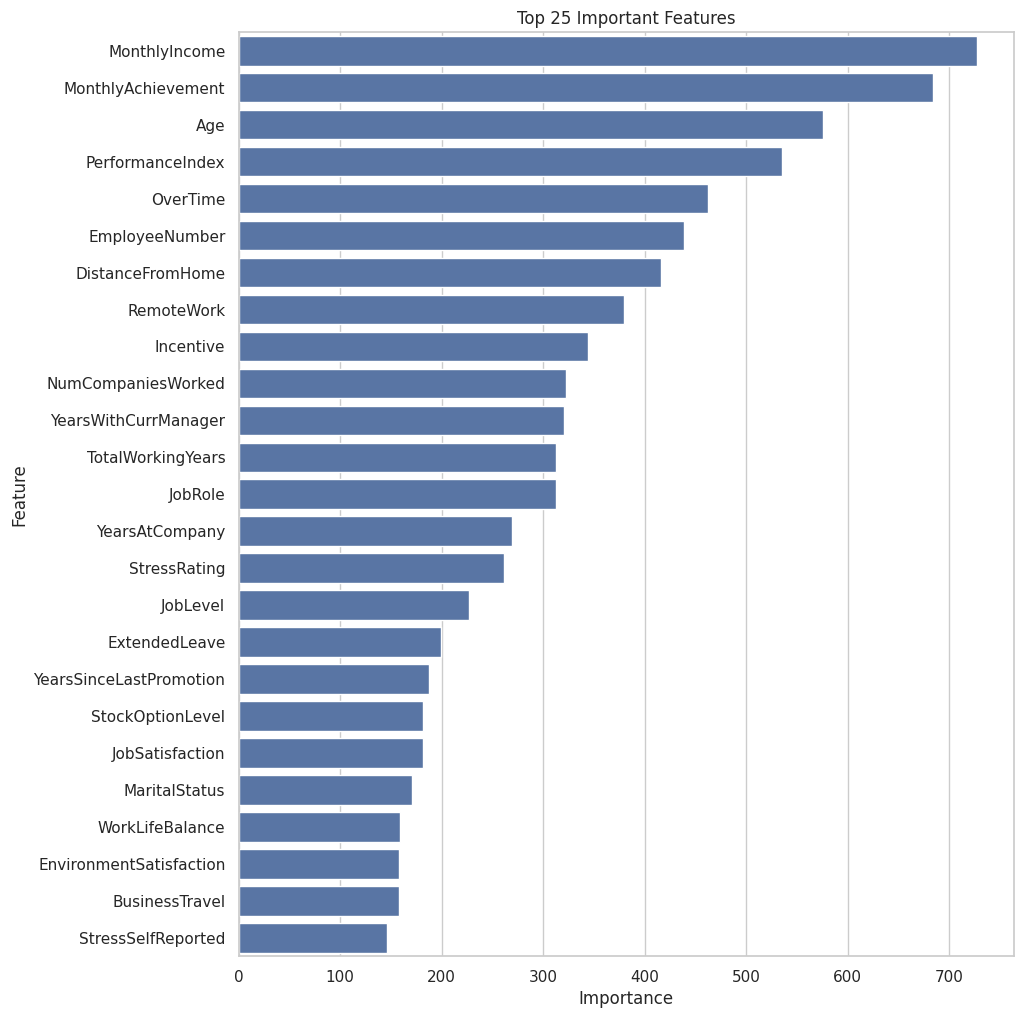

,Feature,Importance
30,MonthlyIncome,727
14,MonthlyAchievement,684
0,Age,576
8,PerformanceIndex,535
16,OverTime,462
39,EmployeeNumber,439
3,DistanceFromHome,416
29,RemoteWork,380
28,Incentive,344
15,NumCompaniesWorked,322


In [83]:
# =====================================
# 11. FEATURE IMPORTANCE
# =====================================

importances = pd.DataFrame({
    "Feature": X_train.columns,
    "Importance": best_model.feature_importances_
}).sort_values(by="Importance", ascending=False)

plt.figure(figsize=(10, 12))
sns.barplot(data=importances.head(25), x="Importance", y="Feature")
plt.title("Top 25 Important Features")
plt.show()

importances.head(20)


## References

### Books
1. VanderPlas, J. (2016). *Python Data Science Handbook*. O'Reilly Media.
2. Géron, A. (2019). *Hands-On Machine Learning with Scikit-Learn, Keras and TensorFlow* (2nd ed.). O'Reilly Media.
3. James, G., et al. (2021). *An Introduction to Statistical Learning* (2nd ed.). Springer.

### Python Libraries
4. McKinney, W. (2011). pandas: a Foundational Python Library for Data Analysis.
5. Pedregosa, F., et al. (2011). Scikit-learn: Machine Learning in Python. *JMLR*, 12, 2825–2830.
6. Ke, G., et al. (2017). LightGBM: A Highly Efficient Gradient Boosting Decision Tree. *NIPS 2017*.

### Websites
7. [kaggle.com] (https://www.kaggle.com/code/ayushidhariwal/employee-attrition-analysis)
8. [towardsdatascience.com](https://towardsdatascience.com/cracking-the-employee-attrition-problem-with-machine-learning-6ee751ec4aae/)

### Methodologies
9. Raschka, S. (2018). Model Evaluation, Model Selection, and Algorithm Selection in Machine Learning. arXiv:1811.12808.
10. Sokolova, M., & Lapalme, G. (2009). A systematic analysis of performance measures for classification tasks. *Information Processing & Management*, 45(4), 427-437.

### Data Sources
11. [Dataset](https://drive.google.com/file/d/1MRgT5pYTSaaEKV37VLJ92iR49eWuBvGM/view?usp=drive_link), Retrieved from GCI.